In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

from file_reading import pd_read_exp_file
import lorentz_fit as lorentz
import plotting

## **Experiment B**

In [2]:
# lowest_harmonic = 274.25448868690813
lowest_harmonic = 125

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 1.0, 'current_temp': 69.980430186, 'current_temp_err': 0.00211013261159623, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 3}


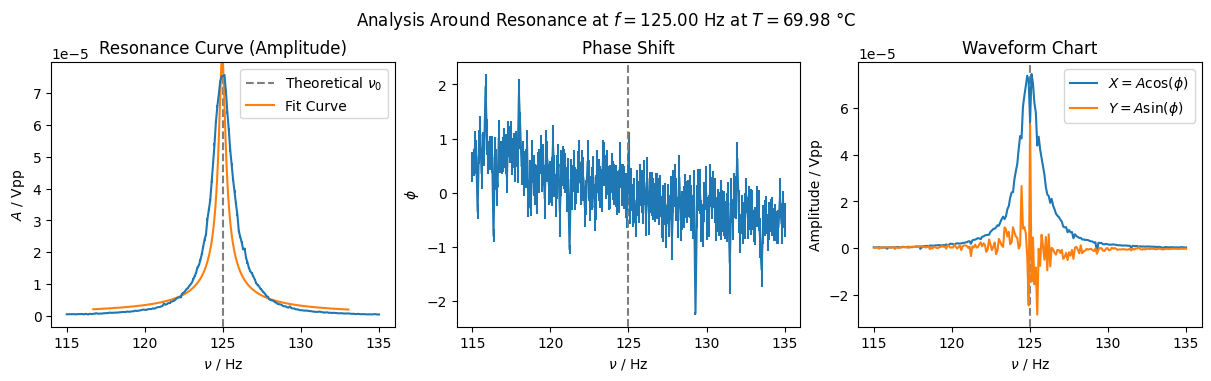

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.8888888888888888, 'current_temp': 72.00790907400004, 'current_temp_err': 0.0008845575174610274, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


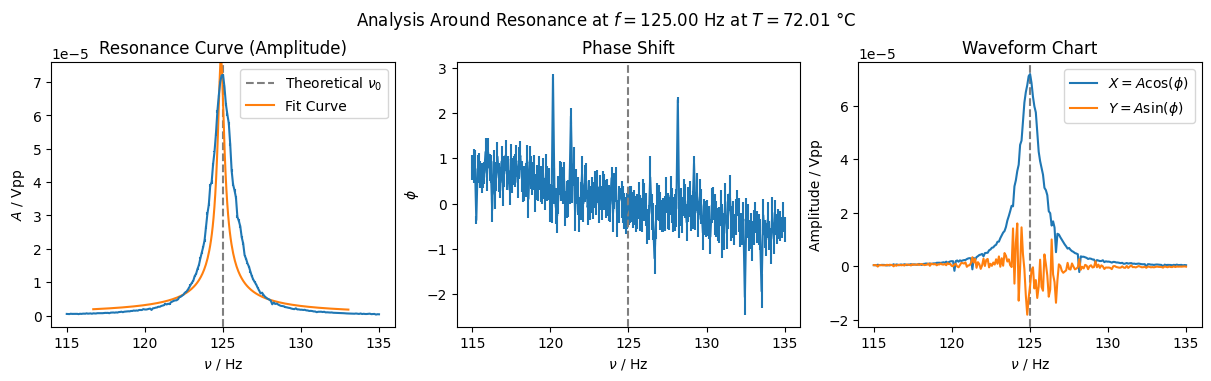

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.7777777777777777, 'current_temp': 73.80723177, 'current_temp_err': 0.0, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 1}


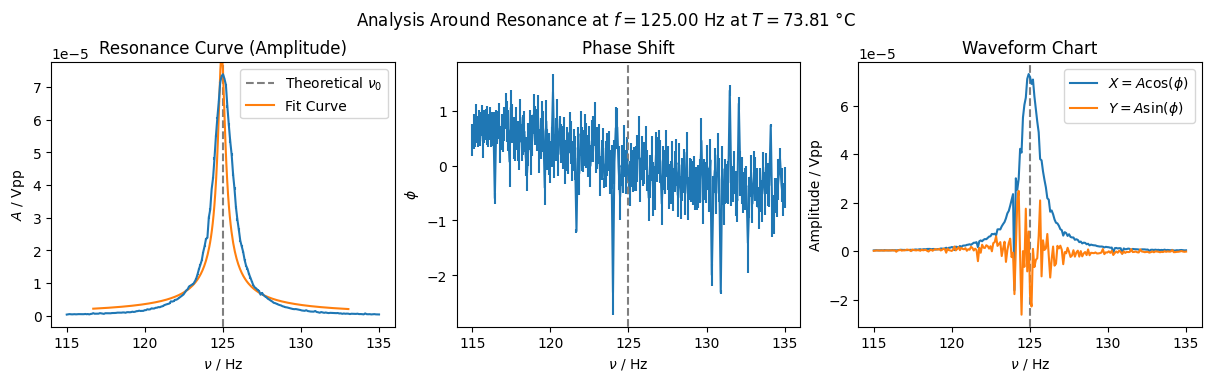

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.6666666666666666, 'current_temp': 73.80723177, 'current_temp_err': 0.0, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


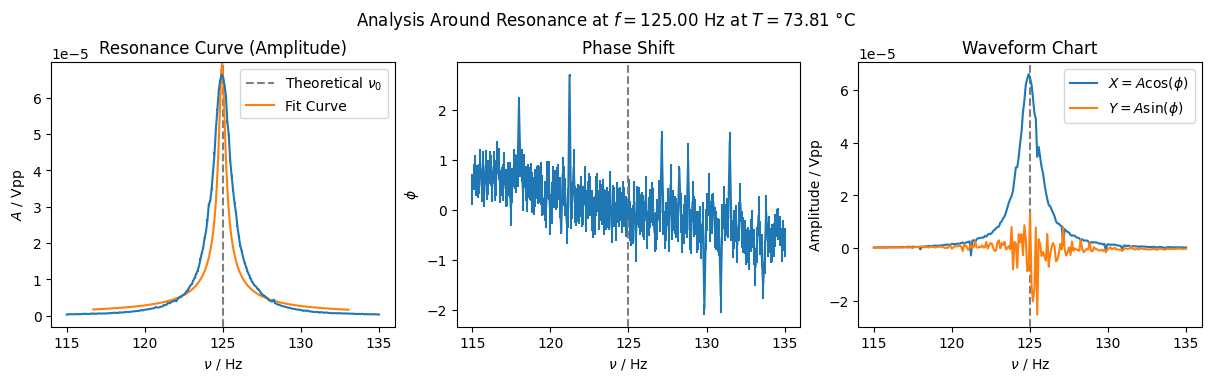

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.5555555555555556, 'current_temp': 69.91302040200001, 'current_temp_err': 0.0005159376016774748, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


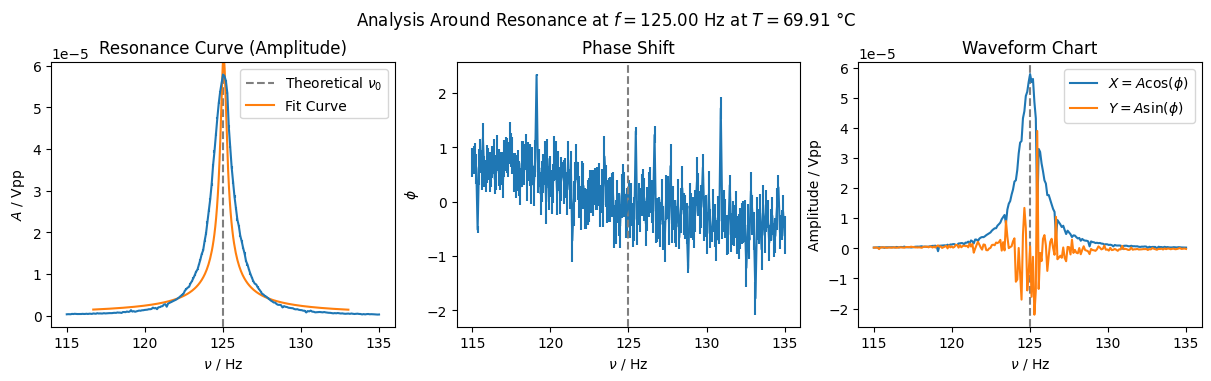

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.4444444444444444, 'current_temp': 62.783139402000046, 'current_temp_err': 0.0030562895062528073, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


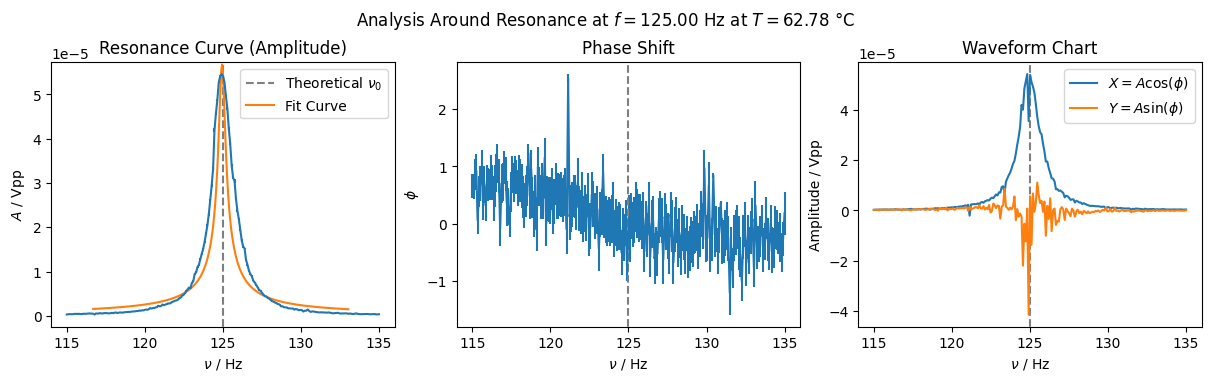

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.3333333333333333, 'current_temp': 55.775114550000055, 'current_temp_err': 0.002777320083574138, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


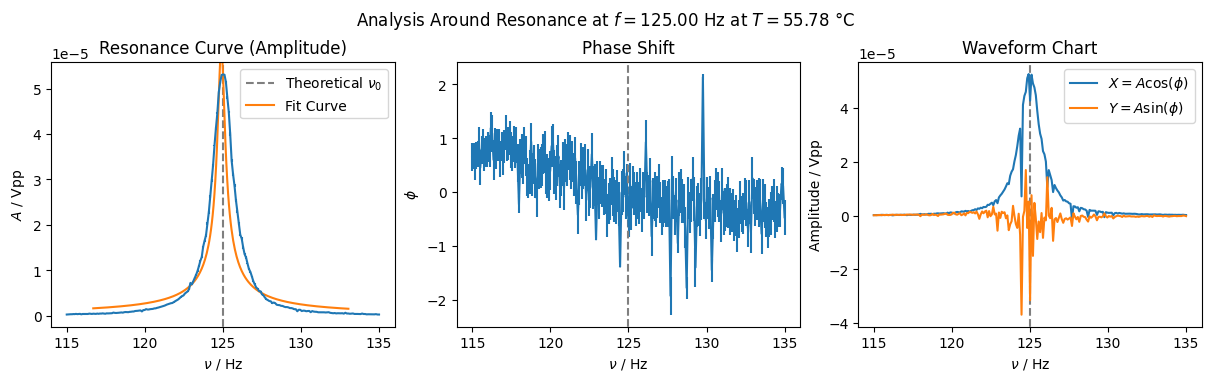

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.2222222222222222, 'current_temp': 49.18451182200002, 'current_temp_err': 0.000773906402516233, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


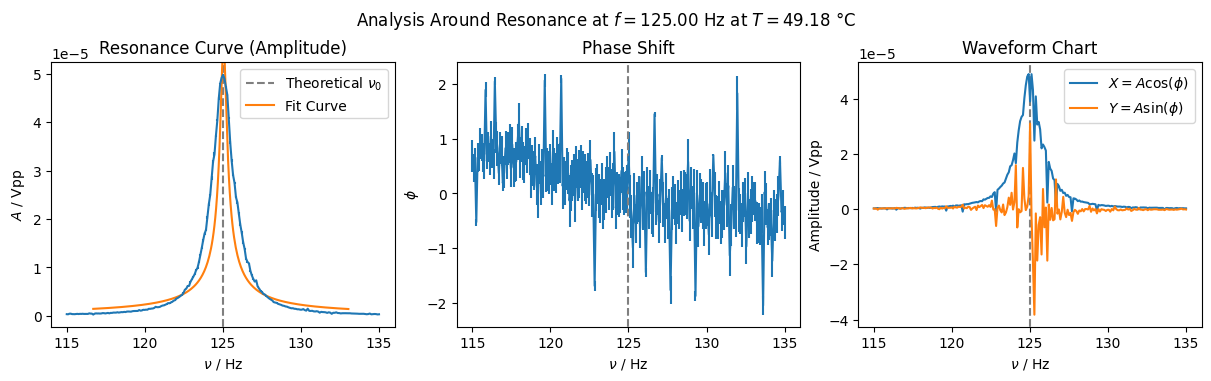

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.1111111111111111, 'current_temp': 42.695023770000034, 'current_temp_err': 7.105427357601002e-17, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 1}


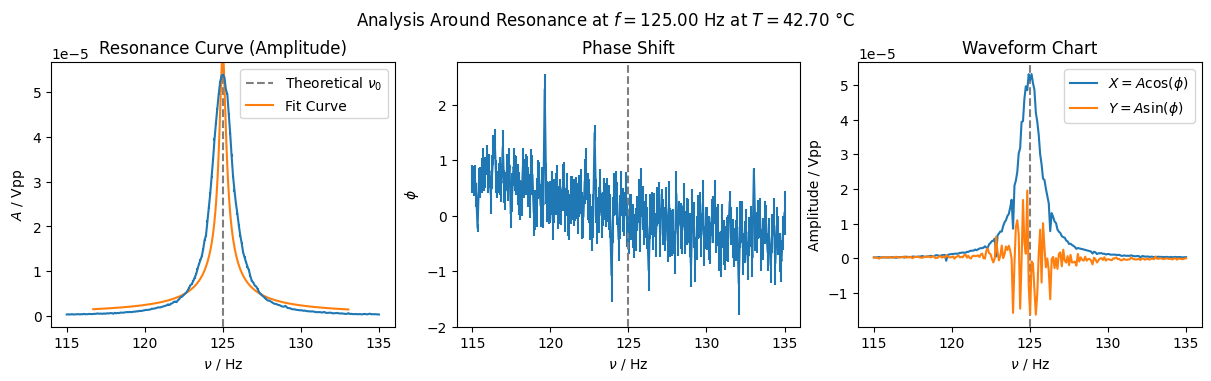

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.0, 'current_temp': 38.82933192599999, 'current_temp_err': 0.0013268362761916135, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


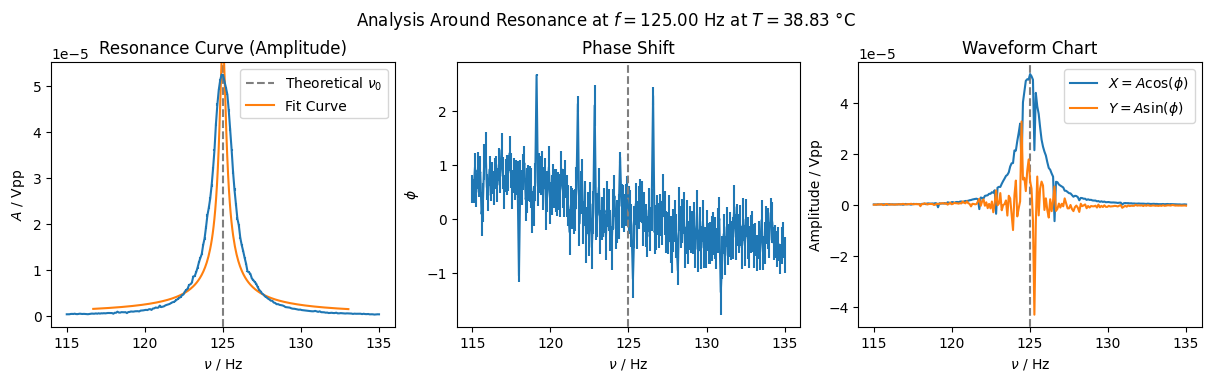

In [3]:
# locs = [
#     "temp0_data_0708_212553.txt",
#     "temp1_data_0708_230411.txt",
#     "temp2_data_0709_002229.txt",
#     "temp3_data_0709_014047.txt",
#     "temp4_data_0709_025905.txt",
#     "temp5_data_0709_041723.txt",
#     "temp6_data_0709_053541.txt",
#     "temp8_data_0709_081217.txt",
#     "temp7_data_0709_065359.txt",
#     "temp9_data_0709_093035.txt",
# ]
# path = "Data/Night Measurement/Experiment_B/"
# locs = [path + loc for loc in locs]
locs = [
    "./Data/Night Measurement 3/voltage0_data_0713_135004.txt",
    "./Data/Night Measurement 3/voltage1_data_0713_152824.txt",
    "./Data/Night Measurement 3/voltage2_data_0713_164642.txt",
    "./Data/Night Measurement 3/voltage3_data_0713_181141.txt",
    "./Data/Night Measurement 3/voltage4_data_0713_192958.txt",
    "./Data/Night Measurement 3/voltage5_data_0713_204816.txt",
    "./Data/Night Measurement 3/voltage6_data_0713_220634.txt",
    "./Data/Night Measurement 3/voltage7_data_0713_232452.txt",
    "./Data/Night Measurement 3/voltage8_data_0714_004310.txt",
    "./Data/Night Measurement 3/voltage9_data_0714_020809.txt",
]

fitparam_results: list[dict] = []

for i, loc in enumerate(locs):
    data, metadata = pd_read_exp_file(loc)
    print(metadata)
    temp = metadata["current_temp"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plotting.pd_freq_spectrum(fig, axs, data)
    for ax in axs:
        plotting.vertical_line(ax, lowest_harmonic, label=r"Theoretical $\nu_0$")

    result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic, "target_voltage": metadata["target_voltage"]}
    # result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic}
    min_idx, max_idx = (20, -20)
    result_dict = result_dict | lorentz.do_fit(axs[0], data["freq"][min_idx:max_idx], data["A"][min_idx:max_idx], data["A_err"][min_idx:max_idx])
    fitparam_results.append(result_dict)

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz at $ T = {temp:.2f} $ °C")
    plt.show()

In [4]:
expB_df = pd.DataFrame(fitparam_results)
df = pd.DataFrame(fitparam_results)
df.pop('params_list')
df.pop('params_err_list')

display(df)

,current_temp,target_freq,target_voltage,f_0,f_0_err,omega_0,omega_0_err,gamma,gamma_err,fit_Q_factor,fit_Q_err
0,69.980430,125,1.000000,0.161626,0.000316,785.114553,0.004718,-2.520228,0.006728,-311.525213,-5.184339e+07
1,72.007909,125,0.888889,0.148342,0.000283,784.630132,0.005229,2.444251,0.006782,321.010475,4.816798e+07
2,73.807232,125,0.777778,0.169876,0.000264,784.894724,0.003311,2.685225,0.005914,292.301282,6.929869e+07
3,73.807232,125,0.666667,0.136850,0.000257,785.052756,0.004298,-2.506176,0.005730,-313.247209,-5.721177e+07
4,69.913020,125,0.555556,0.119920,0.000220,785.696248,0.003688,2.439917,0.005954,322.017611,6.859446e+07
5,62.783139,125,0.444444,0.121681,0.000214,785.047880,0.004183,2.728905,0.005643,287.678698,5.398727e+07
6,55.775115,125,0.333333,0.129877,0.000186,784.759578,0.003624,2.792354,0.006163,281.038667,6.086492e+07
7,49.184512,125,0.222222,0.113244,0.000200,785.657092,0.004493,2.577852,0.007104,304.772032,5.328773e+07
8,42.695024,125,0.111111,0.117966,0.000210,785.342310,0.003807,2.556617,0.006178,307.180324,6.337507e+07
9,38.829332,125,0.000000,0.119533,0.000201,785.370467,0.004081,-2.556725,0.006669,-307.178310,-5.911881e+07


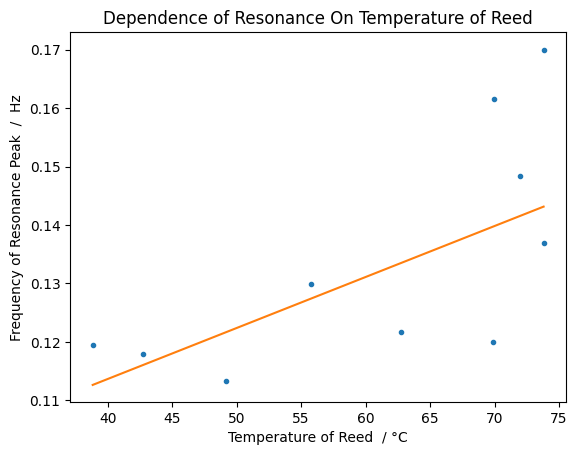

Temperature Coefficient: 0.0008724127983511007 ± 5.664720630127206e-06


In [5]:
fig, ax = plt.subplots()
ax.errorbar(expB_df["current_temp"], expB_df["f_0"], yerr=expB_df["f_0_err"], linestyle="", marker='.')

params, pcov = curve_fit((lambda x, m, c: m * x + c), expB_df["current_temp"], expB_df["f_0"], sigma=expB_df["f_0_err"], absolute_sigma=True)
params_err = np.sqrt(np.diag(pcov))

xspace = np.linspace(np.min(expB_df["current_temp"]), np.max(expB_df["current_temp"]), 50)
ax.plot(xspace, params[0] * xspace + params[1])

ax.set_xlabel("Temperature of Reed  / °C")
ax.set_ylabel("Frequency of Resonance Peak  /  Hz")
ax.set_title("Dependence of Resonance On Temperature of Reed")

plt.show()

print(f"Temperature Coefficient: {params[0]} ± {params_err[0]}")

In [6]:
# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

